**What are we doing?**  
We have demographic data for ~900,000 German citizens AND data for existing customers of a mail-order company.  
Our goal is to find `which types of people` are most likely to become customers, so the company can send marketing only to them => saving money.

## Imports

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

## Load Data

In [50]:
azdias = pd.read_csv("Data/Udacity_AZDIAS_Subset.csv",sep=';')
customers = pd.read_csv("Data/Udacity_CUSTOMERS_Subset.csv",sep=';')

In [51]:
azdias.shape

(891221, 85)

In [52]:
customers.shape

(191652, 85)

In [53]:
azdias.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [54]:
print(azdias.dtypes.value_counts())

float64    49
int64      32
str         4
Name: count, dtype: int64


In [55]:
print('Null Count :',azdias.isnull().sum().sum())

Null Count : 4896838


## Exploring Data

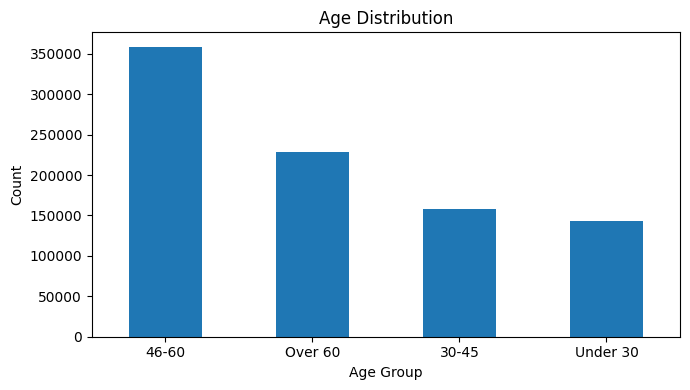

In [56]:
age_labels = {1: 'Under 30', 2: '30-45', 3: '46-60', 4: 'Over 60'}

age_counts = azdias['ALTERSKATEGORIE_GROB'].replace(-1, np.nan).dropna()
age_counts = age_counts.map(age_labels).value_counts()

plt.figure(figsize=(7, 4))
age_counts.plot(kind='bar')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

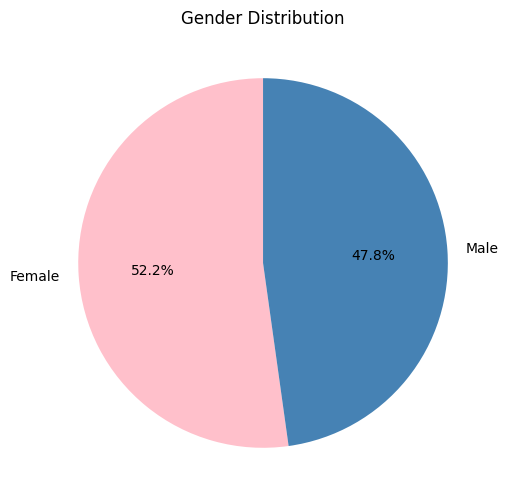

In [57]:
gender_labels = {1: 'Male', 2: 'Female'}

gender_counts = azdias['ANREDE_KZ'].replace([-1,0], np.nan).dropna()
gender_counts = gender_counts.map(gender_labels).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',startangle=90,colors=['pink','steelblue'])
plt.title('Gender Distribution')
plt.show()

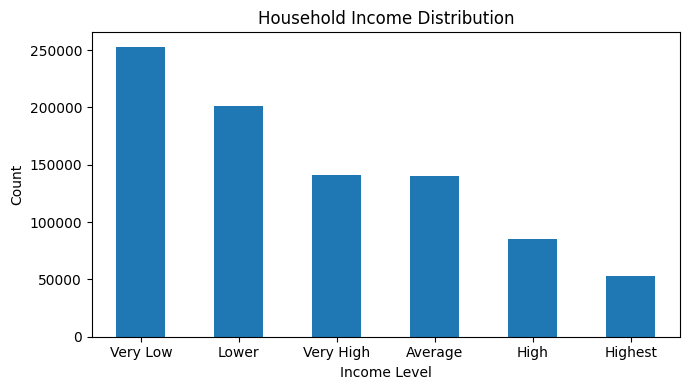

In [58]:
income_labels = {1:'Highest', 2:'Very High', 3:'High', 4:'Average', 5:'Lower', 6:'Very Low'}

income_counts = azdias['HH_EINKOMMEN_SCORE'].replace([-1,0], np.nan).dropna()
income_counts = income_counts.map(income_labels).value_counts()

plt.figure(figsize=(7, 4))
income_counts.plot(kind='bar')
plt.title('Household Income Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Data Cleaning

- we can find that the data has `unknown` data as **-1 , 0 , 9** not as **NaN**.
  So we need to replace it with `NaN`
- Drop columns which have >30% missing (`mostly missing`)
- Drop rows which have too missing values
- Fill remaining with **median**



In [59]:
UNKNOWN_CODES = {
    'AGER_TYP'             : [-1],
    'ALTERSKATEGORIE_GROB' : [-1],
    'ANREDE_KZ'            : [-1],
    'FINANZ_MINIMALIST'    : [-1],
    'FINANZ_SPARER'        : [-1],
    'FINANZ_VORSORGER'     : [-1],
    'FINANZ_ANLEGER'       : [-1],
    'FINANZ_UNAUFFAELLIGER': [-1],
    'FINANZ_HAUSBAUER'     : [-1],
    'FINANZTYP'            : [-1],
    'GEBURTSJAHR'          : [0],
    'HEALTH_TYP'           : [-1],
    'NATIONALITAET_KZ'     : [-1],
    'PRAEGENDE_JUGENDJAHRE': [-1, 0],
    'SHOPPER_TYP'          : [-1],
    'SEMIO_SOZ'            : [-1, 9],
    'SEMIO_FAM'            : [-1, 9],
    'SEMIO_REL'            : [-1, 9],
    'SEMIO_MAT'            : [-1, 9],
    'SEMIO_VERT'           : [-1, 9],
    'SEMIO_LUST'           : [-1, 9],
    'SEMIO_ERL'            : [-1, 9],
    'SEMIO_KULT'           : [-1, 9],
    'SEMIO_RAT'            : [-1, 9],
    'SEMIO_KRIT'           : [-1, 9],
    'SEMIO_DOM'            : [-1, 9],
    'SEMIO_KAEM'           : [-1, 9],
    'SEMIO_PFLICHT'        : [-1, 9],
    'SEMIO_TRADV'          : [-1, 9],
    'VERS_TYP'             : [-1],
    'ZABEOTYP'             : [-1, 9],
    'ALTER_HH'             : [0],
    'HH_EINKOMMEN_SCORE'   : [-1],
    'KK_KUNDENTYP'         : [-1],
    'W_KEIT_KIND_HH'       : [-1],
    'WOHNDAUER_2008'       : [-1],
    'ANZ_HAUSHALTE_AKTIV'  : [0],
    'GEBAEUDETYP'          : [-1],
    'MIN_GEBAEUDEJAHR'     : [0],
    'OST_WEST_KZ'          : [-1],
    'WOHNLAGE'             : [-1],
    'CAMEO_DEUG_2015'      : [-1, 'X'],
    'CAMEO_INTL_2015'      : [-1, 'XX'],
    'KBA05_ANTG1'          : [-1],
    'KBA05_ANTG2'          : [-1],
    'KBA05_ANTG3'          : [-1],
    'KBA05_ANTG4'          : [-1],
    'KBA05_BAUMAX'         : [-1, 0],
    'KBA05_GBZ'            : [-1, 0],
    'BALLRAUM'             : [-1],
    'EWDICHTE'             : [-1],
    'INNENSTADT'           : [-1],
    'KKK'                  : [-1, 0],
    'REGIOTYP'             : [-1, 0],
    'PLZ8_ANTG1'           : [-1],
    'PLZ8_ANTG2'           : [-1],
    'PLZ8_ANTG3'           : [-1],
    'PLZ8_ANTG4'           : [-1],
    'PLZ8_BAUMAX'          : [-1, 0],
    'PLZ8_HHZ'             : [-1],
    'PLZ8_GBZ'             : [-1],
    'ARBEIT'               : [-1, 9],
    'ORTSGR_KLS9'          : [-1],
    'RELAT_AB'             : [-1, 9],
}

print(f'Unknown-code map ready for {len(UNKNOWN_CODES)} columns.')

Unknown-code map ready for 64 columns.


In [60]:
def clean_data(df,unkown_codes, drop_cols=None, row_thresh=None):
    df = df.copy()

    # Replace "unkown" with NaN
    for col , vals in unkown_codes.items():
        if col in df.columns:
            df[col] = df[col].replace(vals , np.nan)

    # Drop Cols with >30% missing
    if drop_cols is None:
        drop_cols = df.columns[df.isnull().mean() > 0.30].tolist()
        drop_cols += ['CAMEO_DEU_2015']  # string column ==> not needed
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Drop Rows 
    if row_thresh is None:
        row_thresh = df.isnull().sum(axis=1).quantile(0.95)
    df = df[df.isnull().sum(axis=1) <= row_thresh]

    # Encode the only text column
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'O': 0, 'W': 1})

    # Fill NaN with median
    imp = SimpleImputer(strategy='median')
    df = pd.DataFrame(
        imp.fit_transform(df),
        columns=df.columns,
        index=df.index
    )

    return df , drop_cols ,row_thresh

In [61]:
print('Before cleaning:')
print(f'General population : {azdias.shape}')
print(f'Customers          : {customers.shape}')

Before cleaning:
General population : (891221, 85)
Customers          : (191652, 85)


In [62]:
# Clean population first ==> set our thresholds
azdias_clean, dropped_cols, row_thresh = clean_data(azdias, UNKNOWN_CODES)

# Clean customers using the same thresholds
customers_clean, _, _ = clean_data(
    customers,
    UNKNOWN_CODES,
    drop_cols=dropped_cols,
    row_thresh=row_thresh
)

print('After cleaning:')
print(f'General population : {azdias_clean.shape}')
print(f'Customers          : {customers_clean.shape}')
print(f'Columns dropped    : {len(dropped_cols)}')

After cleaning:
General population : (891189, 79)
Customers          : (191622, 79)
Columns dropped    : 6


## Feature Scalling

In [65]:
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_clean)
customers_scaled = scaler.transform(customers_clean) # only transform ==> because we only fit on population
print('Done Scalling')

Done Scalling
